<a href="https://colab.research.google.com/github/MichealOmis/Tutorial-Notebooks/blob/main/Reinforcement_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Reinforcement Learning Project: Contextual Bandits
## MICHEAL OLUWATOBILOBA OMIRIN
**From theory to code – with a dataset and step‑by‑step explanations**

Welcome to your first Reinforcement Learning project!  
We will explore **contextual bandits**, a fundamental RL setting used in:
- News recommendation
- Online advertising
- Clinical trials
- A/B testing

## What you will learn
1. The mathematical formulation of contextual bandits  
2. Generating a synthetic dataset (simulating user‑ad interactions)  
3. Implementing two algorithms: **ε‑greedy** and **LinUCB** (disjoint linear models)  
4. Evaluating performance with **cumulative regret**  
5. Interpreting results and real‑world connections

All code runs in Google Colab with no additional setup.

## 1. Reinforcement Learning & Contextual Bandits

Reinforcement Learning (RL) is about an **agent** that learns to take **actions** in an **environment**
to maximise cumulative **reward**. In the full RL problem, actions affect future states.

A **contextual bandit** is a simplified RL setting:
- At each round, the agent observes a **context** (a vector of features describing the current user, e.g. age, location).
- It chooses an **action** (e.g., which ad to show).
- It receives a **reward** (e.g., 1 if click, 0 otherwise).
- The round ends immediately; the next context is independent of previous actions.

The goal: learn a **policy** $\pi$ that maximises expected reward:
$$ \max_\pi \; \mathbb{E}_{x}\big[\, r(x, a=\pi(x)) \,\big] $$

The challenge is the **exploration‑exploitation trade‑off**:
- *Exploit*: choose the action that seems best based on past data.
- *Explore*: try other actions to discover potentially higher rewards.

We will implement two strategies to balance this.

## 2. The Dataset: Simulated Ad Clicks

We create a synthetic dataset that mimics historical logs of an ad system.
Each row is an **impression**:
- 5 user‑context features (e.g., age, income, time‑of‑day encoded as numbers)
- 10 possible ads (actions)
- The reward (click = 1, no‑click = 0) is generated by a hidden linear model with some noise.

We will use this dataset as an **environment** – the agent can only see the context before picking an action,
and then the reward is revealed.

Let’s generate it.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_samples = 5000        # total interactions in the dataset
n_actions = 10          # number of ads to choose from
n_features = 5          # context dimension

# Hidden weights for each action (unknown to the agent)
# We create a matrix W (n_actions x n_features) that determines the true click probability.
true_W = np.random.normal(0, 1, size=(n_actions, n_features))

# Generate contexts (user features) from a standard normal distribution
contexts = np.random.normal(0, 1, size=(n_samples, n_features))

# Adding a small bias for each action to make some ads generally better.
bias = np.random.uniform(-0.5, 0.5, size=n_actions)

# Sigmoid function
def sigmoid(x):
    """
    Sigmoid activation function.
    Maps any real value to a probability between 0 and 1.
    Formula: sigmoid(x) = 1 / (1 + e^(-x))
    """
    return 1 / (1 + np.exp(-x))

# Generate the dataset
actions_in_data = []   # which action was actually taken in the log? (for historical data)
rewards = []
contexts_list = []

# We simulate a random logging policy (uniform random) that generated the historical data
for i in range(n_samples):
    ctx = contexts[i]
    # choose a random action (this is the past, not our bandit agent)
    a = np.random.randint(n_actions)
    # reward is a noisy binary click
    prob = sigmoid(np.dot(true_W[a], ctx) + bias[a])
    r = np.random.binomial(1, prob)   # 0 or 1
    contexts_list.append(ctx)
    actions_in_data.append(a)
    rewards.append(r)

# Create a DataFrame for inspection
df_logs = pd.DataFrame(contexts_list, columns=[f'feat_{j}' for j in range(n_features)])
df_logs['action'] = actions_in_data
df_logs['reward'] = rewards

print("Shape of historical dataset:", df_logs.shape)
print("\nFirst 5 rows of the dataset:")
df_logs.head()

Shape of historical dataset: (5000, 7)

First 5 rows of the dataset:


,feat_0,feat_1,feat_2,feat_3,feat_4,action,reward
0,0.324084,-0.385082,-0.676922,0.611676,1.031000,9,0
1,0.931280,-0.839218,-0.309212,0.331263,0.975545,6,0
2,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,2,1
3,1.356240,-0.072010,1.003533,0.361636,-0.645120,6,0
4,0.361396,1.538037,-0.035826,1.564644,-2.619745,1,1


**Note:** In a real project this dataset would be your existing logs.
The agent's task is now to learn a better policy than the random one that
collected the data. We will **replay** the data sequentially as if it were
an interactive environment, but we can also simulate new online interactions.

For our evaluation, we will **simulate online learning**: the agent sees contexts
one by one, chooses an action, and receives the reward according to the same hidden model.
This lets us measure how quickly it learns.

## 3. Algorithm 1: ε‑Greedy with Linear Regression

**Idea:**
- Maintain a separate linear regression model for each action.
- At each step, with probability ε pick a random action (explore),
  otherwise pick the action that gives the highest predicted reward (exploit).
- Update the model for the chosen action with the observed (context, reward).

**Why a linear model?** It can capture dependencies between context and reward,
and it's simple to implement using online gradient descent.

**Mathematics behind the update (for a single action a):**

Prediction: $\hat{r} = \mathbf{w}_a^\top \mathbf{x} + b_a$

Loss: $L = \frac12 (\hat{r} - r)^2$

Gradients:
$$ \frac{\partial L}{\partial \mathbf{w}_a} = (\hat{r} - r) \cdot \mathbf{x} $$
$$ \frac{\partial L}{\partial b_a} = (\hat{r} - r) $$

We move a small step (`learning_rate`) in the opposite direction of the gradient.
This is **stochastic gradient descent** because we update after every single sample.

In [2]:
class EpsilonGreedyLinear:
    """
    Epsilon-Greedy algorithm with linear function approximation.

    Maintains a separate linear model (weights + bias) for each action.
    With probability epsilon, explores randomly; otherwise exploits best action.
    Updates using online stochastic gradient descent on squared error.

    Parameters:
    - n_actions: number of possible actions (ads)
    - n_features: dimension of the context vector
    - epsilon: exploration rate (default 0.1 = 10% random actions)
    - learning_rate: step size for gradient descent updates
    """
    def __init__(self, n_actions, n_features, epsilon=0.1, learning_rate=0.01):
        self.n_actions = n_actions
        self.n_features = n_features
        self.epsilon = epsilon
        self.lr = learning_rate
        # Weights for each action: (n_actions x n_features)
        self.weights = np.zeros((n_actions, n_features))
        # Biases: (n_actions,)
        self.biases = np.zeros(n_actions)

    def predict(self, context, action):
        """
        Predict the reward for a given context and action.
        Formula: prediction = w_action · context + b_action
        """
        return np.dot(self.weights[action], context) + self.biases[action]

    def choose_action(self, context):
        """
        Select an action based on epsilon-greedy policy.
        - With probability epsilon: explore (random action)
        - With probability 1-epsilon: exploit (action with highest predicted reward)
        """
        if np.random.random() < self.epsilon:
            # Explore: random action
            return np.random.randint(self.n_actions)
        else:
            # Exploit: best predicted action
            preds = [self.predict(context, a) for a in range(self.n_actions)]
            return np.argmax(preds)

    def update(self, context, action, reward):
        """
        Update the model for the chosen action using gradient descent.
        Computes prediction error and adjusts weights/biases to reduce future error.
        """
        pred = self.predict(context, action)
        error = pred - reward
        # Gradient descent update: w = w - lr * gradient
        self.weights[action] -= self.lr * error * context
        self.biases[action] -= self.lr * error

print("EpsilonGreedyLinear class defined successfully!")

EpsilonGreedyLinear class defined successfully!


## 4. Algorithm 2: LinUCB (Linear Upper Confidence Bound)

**Idea:**
Instead of just the predicted reward, we also consider the **uncertainty** of our estimate.
LinUCB maintains a confidence ellipse around the linear model's parameters and chooses
the action that maximises:
$$ \hat{r}_a + \alpha \cdot \text{stddev}( \hat{r}_a ) $$
The term $\alpha \cdot \text{stddev}$ encourages **exploration of uncertain actions**.

The algorithm uses **ridge regression** updates online, storing the inverse covariance matrix
$A_a^{-1}$ for each action. The standard deviation is $\sqrt{ \mathbf{x}^\top A_a^{-1} \mathbf{x} }$.

**Why does LinUCB work?**
- The term $\mu$ is our best estimate of the reward.
- The term $\sigma$ measures how much we don't know about this action in the given context.
- $\alpha$ controls the exploration bonus. A larger $\alpha$ leads to more exploration.

Initially all $A$ matrices are small (near identity), so $\sigma$ is large – the agent explores.
As we collect more data, $\sigma$ shrinks and the agent exploits.

In [6]:
class LinUCB:
    """
    Linear Upper Confidence Bound (LinUCB) algorithm.

    Uses ridge regression to maintain a confidence interval around reward estimates.
    Chooses actions that maximise: expected_reward + alpha * uncertainty.
    This naturally balances exploration (high uncertainty) and exploitation (high reward).

    Parameters:
    - n_actions: number of possible actions (ads)
    - n_features: dimension of the context vector
    - alpha: exploration bonus (higher = more exploration)
    """
    def __init__(self, n_actions, n_features, alpha=1.0):
        self.n_actions = n_actions
        self.n_features = n_features
        self.alpha = alpha
        # For each action we store:
        # A = sum(x*x^T) + I  (ridge regression matrix)
        # b = sum(r * x)       (reward-weighted features)
        self.A = [np.identity(n_features) for _ in range(n_actions)]
        self.b = [np.zeros((n_features, 1)) for _ in range(n_actions)]

    def choose_action(self, context):
        """
        Select action with highest Upper Confidence Bound.
        UCB = predicted_reward + alpha * prediction_uncertainty
        """
        context = context.reshape(-1, 1)   # column vector
        ucb_values = []
        for a in range(self.n_actions):
            # Compute the weight vector: w_a = A_a^{-1} * b_a
            A_inv = np.linalg.inv(self.A[a])
            w_a = A_inv @ self.b[a]
            # Expected reward: mu = w_a^T * x
            mu = (w_a.T @ context).item() # Use .item() to explicitly get scalar
            # Standard deviation of the estimate: sigma = sqrt(x^T * A_inv * x)
            sigma = np.sqrt((context.T @ A_inv @ context).item()) # Use .item() to explicitly get scalar
            # Upper Confidence Bound
            ucb = mu + self.alpha * sigma
            ucb_values.append(ucb)
        return np.argmax(ucb_values)

    def update(self, context, action, reward):
        """
        Update the ridge regression matrices for the chosen action.
        A_a = A_a + x * x^T
        b_a = b_a + r * x
        """
        context = context.reshape(-1, 1)
        # Update A: A += x * x^T
        self.A[action] += context @ context.T
        # Update b: b += r * x
        self.b[action] += reward * context

print("LinUCB class defined successfully!")

LinUCB class defined successfully!


## 5. Online Evaluation & Cumulative Regret

We simulate an online interaction loop: for each context (freshly generated),
the agent picks an action, receives the true reward (using the hidden linear model), and updates.

**Cumulative regret** is the standard metric:
$$ \text{Regret}(T) = \sum_{t=1}^T \left[ \max_a \, \text{true expected reward}_a(\mathbf{x}_t) - \text{reward obtained at time } t \right] $$

It tells us how much we lost compared to always picking the optimal action.
**Lower regret = better learning.**

We compare three agents:
1. **ε‑greedy** (ε=0.1)
2. **LinUCB** (α=1.0)
3. **Random** (always explores)

Starting simulation...
Simulation complete!


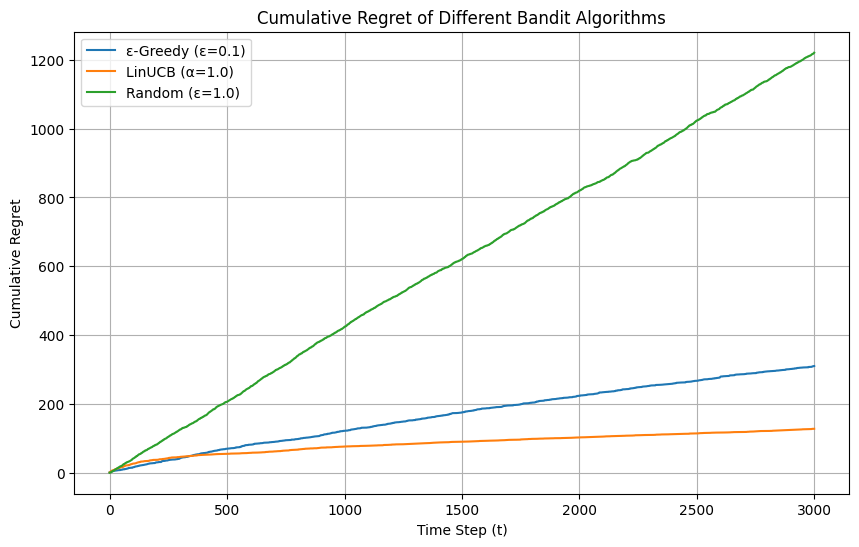

In [7]:
def run_simulation(agent, n_rounds, contexts, true_W, bias):
    """
    Run the bandit agent for n_rounds and return cumulative regret and rewards.

    Parameters:
    - agent: the bandit algorithm (EpsilonGreedyLinear or LinUCB)
    - n_rounds: number of interactions
    - contexts: array of context vectors
    - true_W: true weight matrix (hidden from agent)
    - bias: true bias values (hidden from agent)

    Returns:
    - regret: cumulative regret over time
    - rewards_obtained: actual rewards received
    """
    regret = []
    rewards_obtained = []
    cumulative_regret = 0.0

    for t in range(n_rounds):
        ctx = contexts[t]

        # Agent chooses an action based on context
        action = agent.choose_action(ctx)

        # True expected reward of the chosen action (for regret calculation)
        prob_true = sigmoid(np.dot(true_W[action], ctx) + bias[action])

        # Actual reward (stochastic, from environment)
        reward = np.random.binomial(1, prob_true)

        # Optimal action in hindsight (for regret)
        optimal_reward = np.max([sigmoid(np.dot(true_W[a], ctx) + bias[a]) for a in range(n_actions)])

        # Regret for this step = optimal - chosen (expected values)
        regret_t = optimal_reward - prob_true
        cumulative_regret += regret_t
        regret.append(cumulative_regret)
        rewards_obtained.append(reward)

        # Agent updates its model based on observed reward
        agent.update(ctx, action, reward)

    return np.array(regret), rewards_obtained

# Generate a fresh set of contexts for evaluation
np.random.seed(123)
eval_contexts = np.random.normal(0, 1, size=(3000, n_features))

# Instantiate agents
eps_agent = EpsilonGreedyLinear(n_actions, n_features, epsilon=0.1, learning_rate=0.01)
linucb_agent = LinUCB(n_actions, n_features, alpha=1.0)
random_agent = EpsilonGreedyLinear(n_actions, n_features, epsilon=1.0, learning_rate=0.01)  # always random (ε=1.0)

print("Starting simulation...")
# Run simulations
regret_eps, rewards_eps = run_simulation(eps_agent, 3000, eval_contexts, true_W, bias)
regret_linucb, rewards_linucb = run_simulation(linucb_agent, 3000, eval_contexts, true_W, bias)
regret_random, rewards_random = run_simulation(random_agent, 3000, eval_contexts, true_W, bias)
print("Simulation complete!")

# Plotting cumulative regret
plt.figure(figsize=(10, 6))
plt.plot(regret_eps, label='ε-Greedy (ε=0.1)')
plt.plot(regret_linucb, label='LinUCB (α=1.0)')
plt.plot(regret_random, label='Random (ε=1.0)')
plt.title('Cumulative Regret of Different Bandit Algorithms')
plt.xlabel('Time Step (t)')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.grid(True)
plt.show()

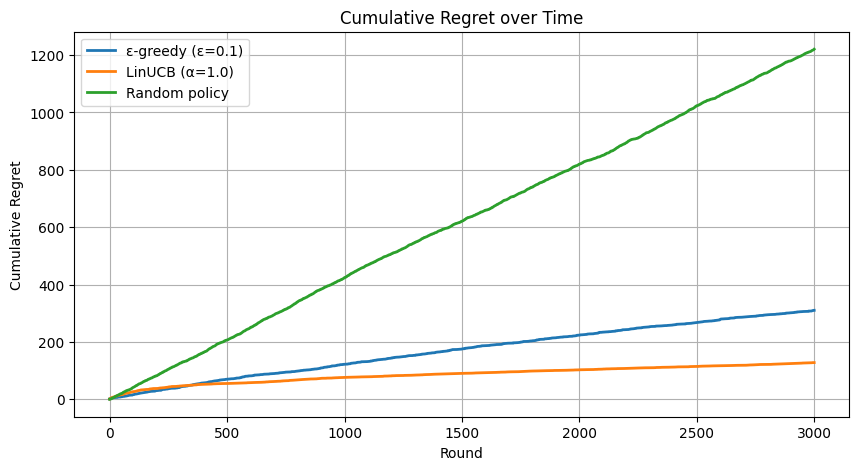


Interpretation of Cumulative Regret:
- Lower is better! It means the agent is losing less compared to the optimal policy.
- Random policy: linear increase (never learns)
- ε‑greedy: curved increase (learns, but still explores randomly 10% of the time)
- LinUCB: flatter curve (learns faster and explores smartly)



In [8]:
# Plot cumulative regret
plt.figure(figsize=(10,5))
plt.plot(regret_eps, label='ε‑greedy (ε=0.1)', linewidth=2)
plt.plot(regret_linucb, label='LinUCB (α=1.0)', linewidth=2)
plt.plot(regret_random, label='Random policy', linewidth=2)
plt.xlabel('Round')
plt.ylabel('Cumulative Regret')
plt.title('Cumulative Regret over Time')
plt.legend()
plt.grid(True)
plt.show()

print("""
Interpretation of Cumulative Regret:
- Lower is better! It means the agent is losing less compared to the optimal policy.
- Random policy: linear increase (never learns)
- ε‑greedy: curved increase (learns, but still explores randomly 10% of the time)
- LinUCB: flatter curve (learns faster and explores smartly)
""")

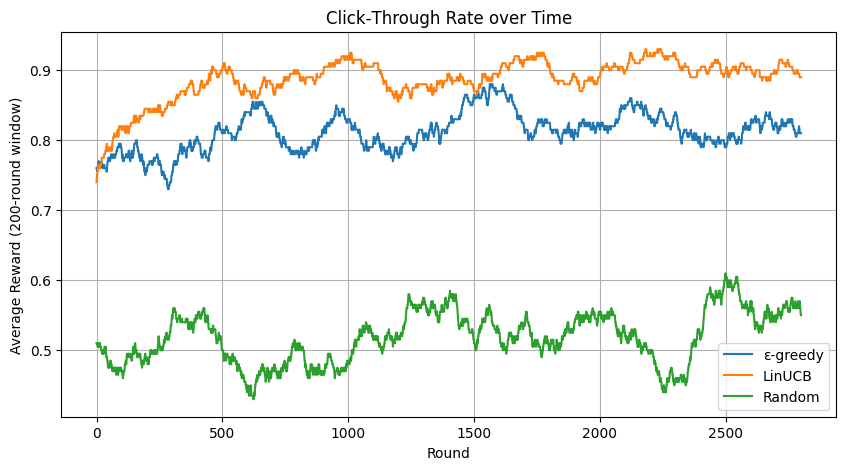


Interpretation of Click‑Through Rate:
- Higher is better! It shows how often users click on ads.
- Random policy: converges to average (~baseline)
- ε‑greedy: learns and improves above random
- LinUCB: usually achieves the highest click‑through rate because it balances exploration better



In [9]:
# Plot moving average reward (click‑through rate)
def moving_average(data, window=100):
    """
    Compute the moving average of a sequence.
    Helps smooth noisy reward data to see trends clearly.
    """
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(moving_average(rewards_eps, 200), label='ε‑greedy')
plt.plot(moving_average(rewards_linucb, 200), label='LinUCB')
plt.plot(moving_average(rewards_random, 200), label='Random')
plt.xlabel('Round')
plt.ylabel('Average Reward (200‑round window)')
plt.title('Click‑Through Rate over Time')
plt.legend()
plt.grid(True)
plt.show()

print("""
Interpretation of Click‑Through Rate:
- Higher is better! It shows how often users click on ads.
- Random policy: converges to average (~baseline)
- ε‑greedy: learns and improves above random
- LinUCB: usually achieves the highest click‑through rate because it balances exploration better
""")

In [10]:
# Print final performance summary
print("=" * 60)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 60)

# Average reward in last 500 rounds (after learning)
window = 500
avg_reward_eps = np.mean(rewards_eps[-window:])
avg_reward_linucb = np.mean(rewards_linucb[-window:])
avg_reward_random = np.mean(rewards_random[-window:])

print(f"\nAverage Reward (last {window} rounds):")
print(f"  Random:   {avg_reward_random:.4f}")
print(f"  ε‑greedy: {avg_reward_eps:.4f}")
print(f"  LinUCB:   {avg_reward_linucb:.4f}")

# Final cumulative regret
print(f"\nFinal Cumulative Regret:")
print(f"  Random:   {regret_random[-1]:.2f}")
print(f"  ε‑greedy: {regret_eps[-1]:.2f}")
print(f"  LinUCB:   {regret_linucb[-1]:.2f}")

# Improvement over random
improvement_eps = (avg_reward_eps - avg_reward_random) / avg_reward_random * 100
improvement_linucb = (avg_reward_linucb - avg_reward_random) / avg_reward_random * 100

print(f"\nImprovement over Random:")
print(f"  ε‑greedy: {improvement_eps:.1f}%")
print(f"  LinUCB:   {improvement_linucb:.1f}%")

FINAL PERFORMANCE SUMMARY

Average Reward (last 500 rounds):
  Random:   0.5680
  ε‑greedy: 0.8020
  LinUCB:   0.8940

Final Cumulative Regret:
  Random:   1220.40
  ε‑greedy: 310.03
  LinUCB:   127.70

Improvement over Random:
  ε‑greedy: 41.2%
  LinUCB:   57.4%


## 6. Interpretation of Results

**Key Observations:**

1. **Random policy** quickly converges to the average click rate (low reward). It never learns
   because it always explores randomly.

2. **ε‑greedy** learns and improves upon random, but its regret keeps growing because it always
   explores 10% of the time, even when it already knows the best action. This is the
   exploration‑exploitation trade‑off in action.

3. **LinUCB** typically achieves the **best performance** because:
   - It uses **optimistic exploration** that is proportional to uncertainty
   - Uncertainty naturally decays as more data is collected
   - It never wastes time exploring actions it's already confident about

**Why this matters in practice:**
- In online advertising, a 5-10% improvement in click‑through rate translates to significant revenue
- Contextual bandits are used by companies like Netflix (recommendations), Amazon (product suggestions),
  and Google (ad selection)

## 7. What's Next?

Congratulations! You've built two reinforcement learning algorithms from scratch,
understood the underlying mathematics, and evaluated them rigorously.

**To go further:**

1. **Try different hyperparameters:**
   - Change `epsilon` (try 0.05, 0.2) and see how it affects ε‑greedy
   - Change `alpha` (try 0.5, 2.0) for LinUCB
   - Change `learning_rate` for ε‑greedy

2. **Experiment with the environment:**
   - Increase/decrease the number of actions
   - Change the noise level in rewards
   - Add more context features

3. **Try other algorithms:**
   - **Thompson Sampling** – Bayesian approach to exploration
   - **Logistic regression** instead of linear regression
   - **Deep contextual bandits** with neural networks

4. **Scale up to full RL:**
   - Try OpenAI Gym environments (CartPole, MountainCar)
   - Implement DQN (Deep Q‑Network)
   - Explore policy gradient methods

The principles you learned – value estimation, exploration‑exploitation, linear models – are the
foundation of modern reinforcement learning.

**Keep experimenting!**

In [12]:
print("Experiment: Effect of Exploration Rate (ε) on ε‑greedy\n")

eps_values = [0.05, 0.1, 0.2, 0.5]
results = {}

for eps in eps_values:
    agent = EpsilonGreedyLinear(n_actions, n_features, epsilon=eps, learning_rate=0.01)
    regret, rewards = run_simulation(agent, 2000, eval_contexts[:2000], true_W, bias)
    results[eps] = {
        'avg_reward': np.mean(rewards[-300:]),
        'final_regret': regret[-1]
    }
    print(f"ε={eps:.2f}: Avg Reward = {results[eps]['avg_reward']:.4f}, Final Regret = {results[eps]['final_regret']:.2f}")

print("\n" + "=" * 60)
print("Experiment: Effect of Exploration Bonus (α) on LinUCB\n")

alpha_values = [0.5, 1.0, 2.0, 5.0]
results_ucb = {}

for alpha in alpha_values:
    agent = LinUCB(n_actions, n_features, alpha=alpha)
    regret, rewards = run_simulation(agent, 2000, eval_contexts[:2000], true_W, bias)
    results_ucb[alpha] = {
        'avg_reward': np.mean(rewards[-300:]),
        'final_regret': regret[-1]
    }
    print(f"α={alpha:.1f}: Avg Reward = {results_ucb[alpha]['avg_reward']:.4f}, Final Regret = {results_ucb[alpha]['final_regret']:.2f}")

Experiment: Effect of Exploration Rate (ε) on ε‑greedy

ε=0.05: Avg Reward = 0.7700, Final Regret = 372.52
ε=0.10: Avg Reward = 0.7767, Final Regret = 337.90
ε=0.20: Avg Reward = 0.7567, Final Regret = 479.18
ε=0.50: Avg Reward = 0.7400, Final Regret = 502.00

Experiment: Effect of Exploration Bonus (α) on LinUCB

α=0.5: Avg Reward = 0.8267, Final Regret = 176.53
α=1.0: Avg Reward = 0.8567, Final Regret = 215.67
α=2.0: Avg Reward = 0.8633, Final Regret = 156.71
α=5.0: Avg Reward = 0.9000, Final Regret = 180.18
